Stripe only downlink example
----------------------------
This notebook shows how to use the stripe to send a QAM signal downlink towards the active radio unit. The signal travels up to the antenna of the active radio unit. Varying the fiber, coupler and amplifier parameters allows to inspect their impact on the AM/AM and PSD plots. These are plotted at the end of the notebook for every stage in the link.

In [1]:
import yaml
import numpy as np

from plotter import plotter
from sub_THz_stripe.radiostripe.radiostripe import RadioStripe
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from wireless_channel.subTHz_channel import Channel
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.amplifier.amplifier import Amplifier
from sub_THz_stripe.combiner.combiner import Combiner
from sub_THz_stripe.coupler.coupler import Coupler
from sub_THz_stripe.phase_shifter.phase_shifter import PhaseShifter
from sub_THz_stripe.splitter.splitter import Splitter
from sub_THz_stripe.utils import calculate_papr

In [2]:
environment = "office_space_inline"

# Read out the config file.
config_file = f"environments/{environment}/config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

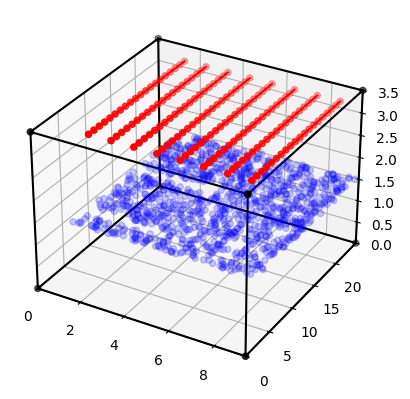

In [3]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [4]:
# Read out the Waveform config file.
config_file = "environments/waveform_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    waveform_config = yaml.safe_load(file)

# Construct the waveform class based on the loaded configuration.
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

ue_pos = None
for ue in config["ue_positions"]:
    if ue["x"] == 2.0 and ue["y"] == 21.5 and ue["z"] == 1.5:
        ue_pos = ue
        break

In [5]:
# Read out the Component config file.
config_file = "environments/component_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    component_config = yaml.safe_load(file)

# Build all the RadioStripe objects based on the configuration.
stripes: list[RadioStripe] = []
for stripe_cfg in config["radio_stripes"]:
    stripes.append(RadioStripe.from_config_locations(stripe_cfg, component_config, config["antenna"]["N_antennas"], wf))

[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272   -0.74849076  0.25192289]
[ 1.022272  

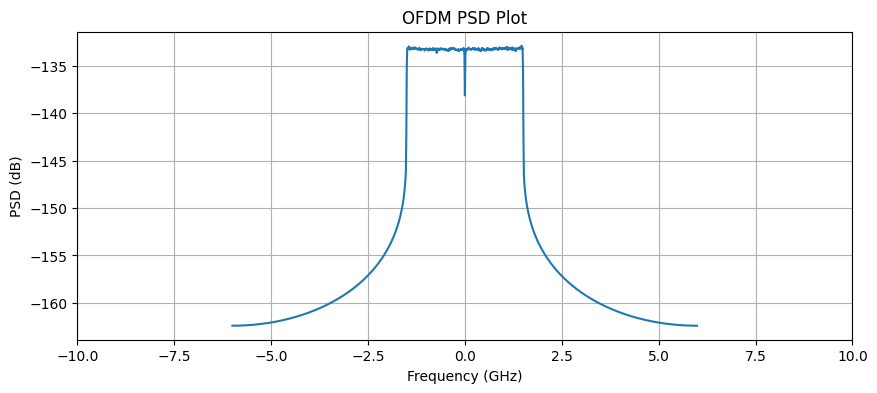

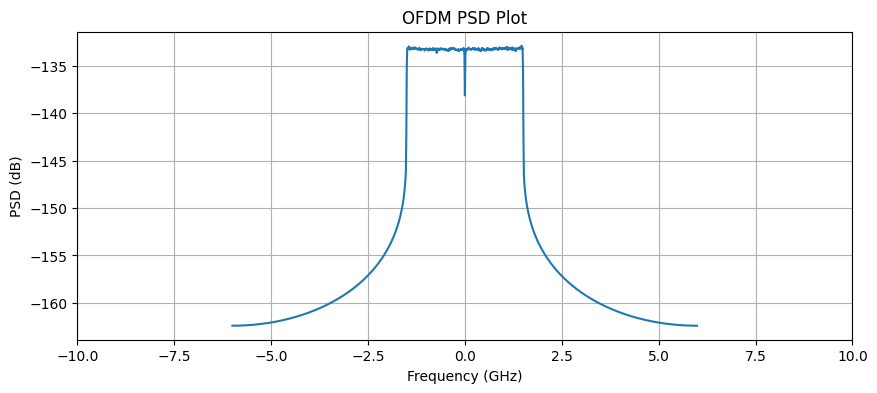

In [6]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)
wf.plot_psd()

In [7]:

cu = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_cu = cu.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

21.00057952247986
[ 1.022272   -0.74849076  0.25192289]
[  4.16726208 -50.7036809  283.58898716]
16.839542453992514
4.076470911078492


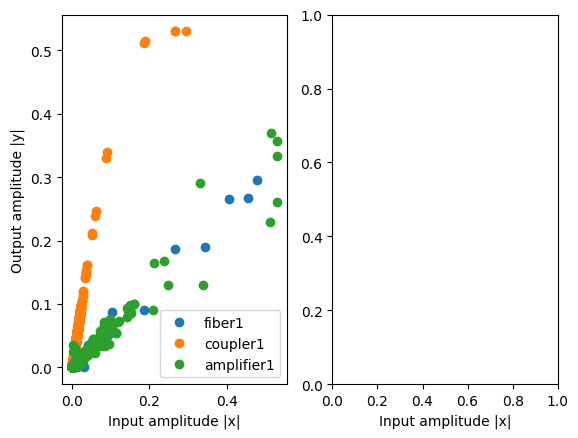

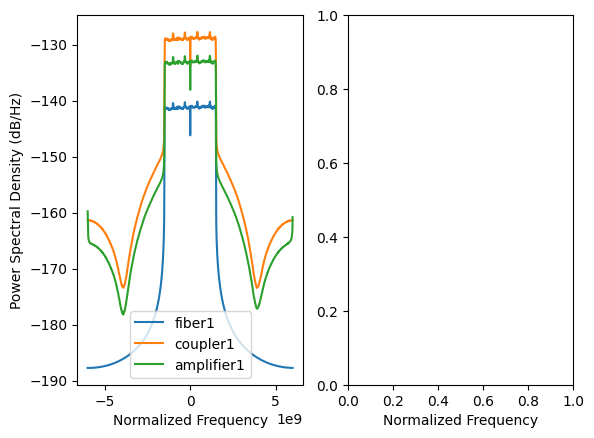

In [8]:
ru_shift = [0, 0, 0, 0]
stripes[0].active_unit = 1
print(calculate_papr(ofdm_time_after_cu, 99.5))
y, imdata = stripes[0].transmit(ofdm_time_after_cu, ru_shift)
print(calculate_papr(imdata[3], 99.5))
print(stripes[0].radio_units[0].boost_amp.gain)

fig, fig2 = plotter.plot_im_data_tx(imdata[1:(1*4)+1], wf)

NMSE: 6.7937746385626765
BER: 0.3196885850694444


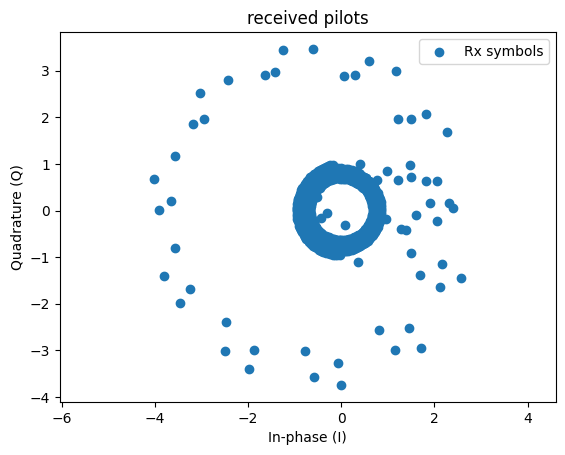

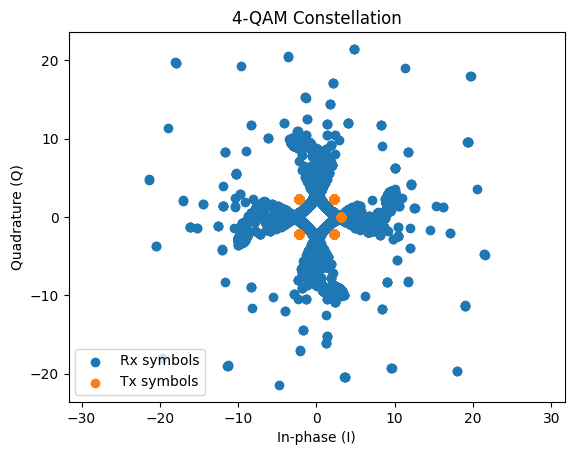

In [9]:
y_combined_freq = wf.ofdm_time_to_freq(imdata[-5])
x_combined_freq = wf.ofdm_time_to_freq(ofdm_time)
xsubc = wf.extract_subcarriers(x_combined_freq)

# sanity check
rx_subc = wf.extract_subcarriers(y_combined_freq)
# look at a few carriers around pilots and data
wf.plot_constellation(rx_subc[0, wf.pilot_indices], title="received pilots")

# channel estimation
subc = wf.extract_subcarriers(y_combined_freq)
H_est = wf.channel_estimate_ls(subc)

# equalization
eq_subc = wf.equalize_one_tap(subc, H_est)

nmse = np.sum(np.abs(eq_subc - xsubc) ** 2) / np.sum(np.abs(xsubc) ** 2)

# Demap data carriers and rebuild stream
data_symbols = wf.demap_data_from_grid(eq_subc).flatten()  # these are the received QAM symbols

y_qam = data_symbols

# quick sanity
assert y_qam.shape[0] == qam.shape[0], f"Lengths differ: rx {y_qam.shape[0]} tx {qam.shape[0]}"

wf.plot_constellation(eq_subc, symbols_tx=xsubc)

y_bits = wf.qam_to_bits(y_qam)

ber = wf.compute_ber(bits, y_bits)
print(f"NMSE: {10 * np.log10(nmse)}")
print(f"BER: {ber}")